In [89]:
import pandas as pd
import numpy as np
import locale
import os

import calendar
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

locale.setlocale(locale.LC_TIME, "es_ES")

'es_ES'

In [40]:
# ------------------------------------------------------------------------------
# Hydrological Status Parameters
# ------------------------------------------------------------------------------

stdStart = 1981
stdEnd = 2010
percentile = [0.10, 0.25, 0.75, 0.90]

values = ['High flow','Above normal','Normal range','Below normal','Low flow']
flow_cat = [5,4,3,2,1]

In [41]:
# ------------------------------------------------------------------------------
# Define plotting position parameters
# Cunnane is alphap = 0.4 and betap = 0.4 
# Weibull is alphap = 0 and betap = 0 
# ------------------------------------------------------------------------------
alphap = 0.4
betap = 0.4

In [77]:
# ------------------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------------------

def _classify(df):
    wr = df['pct_rank']
    criteria = [
        (wr >= percentile[3]) & (wr <= 1.00),
        (wr > percentile[2]) & (wr < percentile[3]),
        (wr >= percentile[1]) & (wr <= percentile[2]),
        (wr >= percentile[0]) & (wr < percentile[1]),
        (wr >= 0.00) & (wr < percentile[0]),
    ]
    df['percentile_range'] = np.select(criteria, values, None)
    df['flowcat'] = np.select(criteria, flow_cat, pd.NA)

def _compute_status(df, group_col, avg_series, anomaly_col,alphap,betap):
    avg_map = df[group_col].map(avg_series)
    df[anomaly_col] = (df['flow'] - avg_map) / avg_map
    df['rank_average'] = df.groupby(group_col)['flow'].rank()
    df['complete%'] = df.groupby(group_col)['flow'].transform(lambda x: x.notnull().sum())
    df['pct_rank'] = (df['rank_average'] - alphap) / (df['complete%'] + 1 - alphap - betap)
    _classify(df)

def import_data(input_directory, filename):
    flowdata = pd.read_csv(f"{input_directory}{filename}", parse_dates=['Fecha'],
                           index_col="Fecha", dayfirst=True, na_values="NA")
    full_range = pd.date_range(start=flowdata.index[0], end=flowdata.index[-1], freq='D')
    flowdata = flowdata.reindex(full_range).rename_axis("date")
    flowdata.columns = ['flow']
    station = filename.split('.')[0]

    flowdata['month'] = flowdata.index.month
    flowdata['year'] = flowdata.index.year
    flowdata['day'] = flowdata.index.day
    flowdata['monthday'] = flowdata.index.day_of_year
    flowdata['water_year'] = flowdata.index.year.where(flowdata.index.month < 4, flowdata.index.year + 1)
    # Del 1 al 10 -> 1 | Del 11 al 20 -> 2 | Del 21 al 31 -> 3
    flowdata['dekad_month'] = pd.cut(
    flowdata['day'], bins=[0, 10, 20, 31], labels=[1, 2, 3]).astype(int)

    # Decadia en el año (1 a 36)
    flowdata['dekad_year'] = (flowdata['month'] - 1) * 3 + flowdata['dekad_month']
    
    flowdata = flowdata.reset_index()

    n_missing = flowdata['flow'].isnull().sum()
    print(station)
    print(f"There are {flowdata['year'].max() - flowdata['year'].min()} years of data in this file.")
    print(f"There are {n_missing} missing data points, which is {np.round(n_missing / len(flowdata) * 100, 2)}% of the total data")
    return flowdata, station


In [78]:
# ------------------------------------------------------------------------------
# Main functions
# ------------------------------------------------------------------------------

def daily_status(DISCHARGE_DAILY):
    avg = DISCHARGE_DAILY[
        (DISCHARGE_DAILY['year'] >= stdStart) & (DISCHARGE_DAILY['year'] <= stdEnd)
    ].groupby('monthday')['flow'].mean()

    df = DISCHARGE_DAILY.copy()
    _compute_status(df, 'monthday', avg, 'percentile_flow', alphap=alphap, betap=betap)
    return df

def dekad_status(DISCHARGE_DAILY):
    # 1. Agregar a escala decádica con fechas de inicio y fin de cada intervalo
    dekad_df = (
        DISCHARGE_DAILY.groupby(
            ["year", "dekad_year"], as_index=False, observed=True
        )
        .agg(
            startDate=("date", "min"),  # Primer día del cálculo
            endDate=("date", "max"),  # Último día del cálculo
            flow=("flow", "mean"),  # Caudal medio de la decadia (m3/s)
            month=("month", "first"),
            water_year=("water_year", "first"),
            dekad_month=("dekad_month", "first"),
        )
        .sort_values(["year", "dekad_year"])
        .reset_index(drop=True)
    )

    # 2. Climatología de referencia en el período estándar [stdStart, stdEnd]
    avg = dekad_df[
        (dekad_df["year"] >= stdStart) & (dekad_df["year"] <= stdEnd)
    ].groupby("dekad_year")["flow"].mean()

    # 3. Cálculo de estatus sobre la serie decádica
    df = dekad_df.copy()
    _compute_status(
        df, "dekad_year", avg, "percentile_flow", alphap=alphap, betap=betap
    )

    return df, dekad_df

In [156]:
# ------------------------------------------------------------------------------
# Import data
# ------------------------------------------------------------------------------
filename = '26669.csv'  # Replace with your actual filename
input_folder = r'../stations/data/'

df, station = import_data(input_folder, filename)

26669
There are 46 years of data in this file.
There are 341 missing data points, which is 2.0% of the total data


In [157]:
df_daily_status = daily_status(df)
df_dekad_status, df_dekad = dekad_status(df)

In [158]:
def plot_dekad_event_heatmap(
    df,
    years_event,
    start_month=8,
    end_month=7,
    cross_year=None,
    thresholds=None,
    flowcat_col="dekad_status",
    discharge_col="Discharge",
    date_col="Date",
    figsize=(16, 4),
):
    """Genera un heatmap comparativo de eventos hidrológicos a escala decádica.

    Cada mes contiene exactamente 3 decadias (1: días 1-10, 2: días 11-20, 3:
    días 21-fin).
    """
    df_base = df.copy()
    if date_col not in df_base.columns and df_base.index.name == date_col:
        df_base = df_base.reset_index()

    # 1. Asegurar tipos de datos y cálculo de decadias
    df_base[date_col] = pd.to_datetime(df_base[date_col])
    if "month" not in df_base.columns:
        df_base["month"] = df_base[date_col].dt.month
    if "year" not in df_base.columns:
        df_base["year"] = df_base[date_col].dt.year
    if "dekad_month" not in df_base.columns:
        df_base["dekad_month"] = (
            ((df_base[date_col].dt.day - 1) // 10 + 1)
            .clip(upper=3)
            .astype(int)
        )

    df_base[flowcat_col] = pd.to_numeric(df_base[flowcat_col], errors="coerce")
    if discharge_col in df_base.columns:
        df_base[discharge_col] = pd.to_numeric(
            df_base[discharge_col], errors="coerce"
        )

    # Si los datos vienen diarios, agregar por decadia (máximo de categoría / promedio de caudal)
    # Si tus datos ya están a nivel decádico, este groupby mantiene los datos intactos
    agg_dict = {flowcat_col: "max"}
    if discharge_col in df_base.columns:
        agg_dict[discharge_col] = "mean"

    df_base = (
        df_base.groupby(
            ["year", "month", "dekad_month"], as_index=False, observed=True
        )
        .agg(agg_dict)
        .sort_values(["year", "month", "dekad_month"])
    )

    # 2. Determinar si el ciclo cruza el cambio de año
    if cross_year is None:
        is_cross_year = start_month >= end_month
    else:
        is_cross_year = cross_year

    # 3. Construir la plantilla de decadias del ciclo (ej: Agosto a Julio -> 12 meses x 3 = 36 decadias)
    if is_cross_year:
        months_seq = list(range(start_month, 13)) + list(range(1, end_month + 1))
        month_offset = [0] * (13 - start_month) + [1] * end_month
    else:
        months_seq = list(range(start_month, end_month + 1))
        month_offset = [0] * len(months_seq)

    template_rows = []
    idx = 0
    for m, yr_offset in zip(months_seq, month_offset):
        for d in [1, 2, 3]:
            template_rows.append(
                {
                    "month": m,
                    "dekad_month": d,
                    "yr_offset": yr_offset,
                    "dekad_idx": idx,
                }
            )
            idx += 1

    ref_template = pd.DataFrame(template_rows)
    total_dekads = len(ref_template)

    # 4. Alinear los eventos para cada año solicitado
    years_sorted = sorted(years_event)
    frames = []

    for yr in years_sorted:
        sub = ref_template.copy()
        sub["year"] = yr + sub["yr_offset"]
        sub["event_year"] = yr

        # Unir con los datos observados
        merged = pd.merge(
            sub,
            df_base,
            on=["year", "month", "dekad_month"],
            how="left",
        )
        frames.append(merged)

    df_plot = pd.concat(frames, ignore_index=True)

    # 5. Pivotar matriz principal (dekad_status)
    heatmap_values = df_plot.pivot(
        index="event_year", columns="dekad_idx", values=flowcat_col
    ).reindex(index=years_sorted, columns=np.arange(total_dekads))

    # 6. Matriz de umbrales / anotaciones (+)
    has_valid_threshold = bool(
        thresholds
        and len(thresholds) > 0
        and thresholds[0] is not None
        and thresholds[0] > -999
        and discharge_col in df_plot.columns
    )

    if has_valid_threshold:
        df_plot["exceeds_threshold"] = (
            df_plot[discharge_col] >= thresholds[0]
        ).astype(int)
        annot_matrix = (
            df_plot.pivot(
                index="event_year",
                columns="dekad_idx",
                values="exceeds_threshold",
            ).reindex(index=years_sorted, columns=np.arange(total_dekads))
            == 1
        )
        annot_param = np.where(annot_matrix, "+", "")
        annot_kws = {"size": 8, "weight": "bold", "color": "black"}
    else:
        annot_param = False
        annot_kws = None

    # 7. Paleta discreta de colores (1 a 5)
    colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
    bounds = [1, 2, 3, 4, 5, 6]
    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color="#D3D3D3")  # <-- Gris claro para valores NaN (ej: #D3D3D3 o #E0E0E0)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 8. Graficar Heatmap
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        heatmap_values,
        cmap=cmap,
        norm=norm,
        mask=heatmap_values.isna(),
        annot=annot_param,
        fmt="",
        annot_kws=annot_kws,
        linewidths=0.5,
        linecolor="white",  # Líneas sutiles entre decadias
        cbar=False,
        square=False,
        alpha=0.95,
        ax=ax,
    )

    # 9. Etiquetas del eje Y
    if is_cross_year:
        year_labels = [f"{int(y)}/{int(y) + 1}" for y in heatmap_values.index]
    else:
        year_labels = [str(int(y)) for y in heatmap_values.index]

    ax.set_yticks(np.arange(len(heatmap_values.index)) + 0.5)
    ax.set_yticklabels(year_labels, rotation=0, fontsize=11)

    # 10. Etiquetas del eje X (centradas en cada bloque mensual)
    # Como cada mes tiene 3 decadias, el centro exacto está en la decadia del medio (d = 2 -> índice + 1.5)
    month_ticks = [i * 3 + 1.5 for i in range(len(months_seq))]
    month_labels = [calendar.month_abbr[m].upper() for m in months_seq]

    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=11)

    # Opcional: líneas divisorias verticales más marcadas para separar meses
    for m_idx in range(1, len(months_seq)):
        ax.axvline(m_idx * 3, color="black", linewidth=1.0, linestyle="--", alpha=0.3)

    ax.set_xlabel("Meses", fontsize=12, labelpad=8)
    ax.set_ylabel(
        "Eventos" if is_cross_year else "AÑO",
        fontsize=12,
        labelpad=8,
    )

    plt.tight_layout()
    return fig, ax

In [159]:
def plot_daily_event_heatmap(
    df,
    years_event,
    start_month=8,
    end_month=7,
    cross_year=None,
    thresholds=None,
    flowcat_col="status",
    discharge_col="flow",
    date_col="date",
    figsize=(18, 4),
):
    """Genera un heatmap comparativo de eventos hidrológicos a escala diaria.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame con datos diarios.
    years_event : list
        Lista de años de inicio del evento (ej: [1982, 1997, 2015, 2023]).
    start_month : int, default 8
        Mes de inicio del ciclo anual (1 a 12).
    end_month : int, default 7
        Mes de fin del ciclo anual (1 a 12).
    cross_year : bool or None, default None
        Si es True, el ciclo cruza al año siguiente. Infiere True si start_month >= end_month.
    thresholds : list, optional
        Lista con el umbral de caudal (ej: [1750]) para dibujar marcadores '+'.
    flowcat_col : str, default 'status'
        Columna con las categorías hidrológicas discretas (1 a 5).
    discharge_col : str, default 'flow'
        Columna con los valores de caudal.
    date_col : str, default 'date'
        Nombre de la columna o índice de fechas.
    figsize : tuple, default (18, 4)
        Tamaño de la figura en pulgadas.
    """
    df_base = df.copy()
    if date_col not in df_base.columns and df_base.index.name == date_col:
        df_base = df_base.reset_index()

    # 1. Asegurar tipos de datos
    df_base[date_col] = pd.to_datetime(df_base[date_col])
    df_base[flowcat_col] = pd.to_numeric(df_base[flowcat_col], errors="coerce")
    if discharge_col in df_base.columns:
        df_base[discharge_col] = pd.to_numeric(
            df_base[discharge_col], errors="coerce"
        )

    # 2. Determinar si cruza el cambio de año
    if cross_year is None:
        is_cross_year = start_month >= end_month
    else:
        is_cross_year = cross_year

    # 3. Construir plantilla de referencia usando un año bisiesto (2023-2024 o 2024)
    #    para que contemple el día 29 de febrero si el ciclo lo atraviesa
    ref_y_start = 2023 if is_cross_year else 2024
    ref_y_end = 2024 if is_cross_year else 2024

    last_day_end = calendar.monthrange(ref_y_end, end_month)[1]
    t_ref_start = pd.Timestamp(year=ref_y_start, month=start_month, day=1)
    t_ref_end = pd.Timestamp(year=ref_y_end, month=end_month, day=last_day_end)

    ref_dates = pd.date_range(t_ref_start, t_ref_end, freq="D")
    ref_template = pd.DataFrame(
        {
            "rel_date": ref_dates,
            "month": ref_dates.month,
            "day": ref_dates.day,
            "day_idx": np.arange(len(ref_dates)),
        }
    )
    total_days = len(ref_template)

    # 4. Alinear los eventos para cada año solicitado
    years_sorted = sorted(years_event)
    frames = []

    for yr in years_sorted:
        yr_end = yr + 1 if is_cross_year else yr
        last_day = calendar.monthrange(yr_end, end_month)[1]

        t_start = pd.Timestamp(year=yr, month=start_month, day=1)
        t_end = pd.Timestamp(year=yr_end, month=end_month, day=last_day)

        sub = df_base[
            (df_base[date_col] >= t_start) & (df_base[date_col] <= t_end)
        ].copy()

        if not sub.empty:
            sub["month"] = sub[date_col].dt.month
            sub["day"] = sub[date_col].dt.day

            # Unir contra la plantilla mediante mes y día para alinear fechas
            merged = pd.merge(
                ref_template[["month", "day", "day_idx"]],
                sub,
                on=["month", "day"],
                how="left",
            )
            merged["event_year"] = yr
            frames.append(merged)

    if not frames:
        raise ValueError(
            "No se encontraron registros para los períodos especificados."
        )

    df_plot = pd.concat(frames, ignore_index=True)

    # 5. Pivotar matriz principal (categorías diarias)
    heatmap_values = df_plot.pivot(
        index="event_year", columns="day_idx", values=flowcat_col
    ).reindex(index=years_sorted, columns=np.arange(total_days))

    # 6. Matriz de umbrales (+)
    has_valid_threshold = bool(
        thresholds
        and len(thresholds) > 0
        and thresholds[0] is not None
        and thresholds[0] > -999
        and discharge_col in df_plot.columns
    )

    if has_valid_threshold:
        df_plot["exceeds_threshold"] = (
            df_plot[discharge_col] >= thresholds[0]
        ).astype(int)
        annot_matrix = (
            df_plot.pivot(
                index="event_year",
                columns="day_idx",
                values="exceeds_threshold",
            ).reindex(index=years_sorted, columns=np.arange(total_days))
            == 1
        )
        annot_param = np.where(annot_matrix, "+", "")
        annot_kws = {"size": 6, "weight": "bold", "color": "black"}
    else:
        annot_param = False
        annot_kws = None

    # 7. Paleta discreta de colores (1 a 5)
    colors = ["#CD233F", "#FFA885", "#E7E2BC", "#8ECEEE", "#2C7DCD"]
    bounds = [1, 2, 3, 4, 5, 6]
    cmap = mcolors.ListedColormap(colors)
    cmap.set_bad(color="#E0E0E0")  # <-- Gris claro para valores NaN (ej: #D3D3D3 o #E0E0E0)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # 8. Graficar Heatmap
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        heatmap_values,
        cmap=cmap,
        norm=norm,
        mask=heatmap_values.isna(),
        annot=annot_param,
        fmt="",
        annot_kws=annot_kws,
        linewidths=0.0,  # Sin bordes individuales entre días (son ~365 columnas)
        cbar=False,
        square=False,
        alpha=0.95,
        ax=ax,
    )

    # 9. Configuración del eje Y (Años del evento)
    if is_cross_year:
        year_labels = [f"{int(y)}/{int(y) + 1}" for y in heatmap_values.index]
    else:
        year_labels = [str(int(y)) for y in heatmap_values.index]

    ax.set_yticks(np.arange(len(heatmap_values.index)) + 0.5)
    ax.set_yticklabels(year_labels, rotation=0, fontsize=11)

    # 10. Configuración del eje X y separadores mensuales
    month_ticks = []
    month_labels = []

    # Agrupar bloques mensuales continuos según la plantilla
    ref_template["period_block"] = ref_template["rel_date"].dt.to_period("M")
    first_block = True

    for period, group in ref_template.groupby("period_block", sort=False):
        min_idx = group["day_idx"].min()
        max_idx = group["day_idx"].max()

        # Posición central del mes para el label
        mid_point = (min_idx + max_idx) / 2.0
        month_ticks.append(mid_point)
        month_labels.append(calendar.month_abbr[period.month].upper())

        # Línea divisoria vertical al inicio de cada nuevo mes
        if not first_block:
            ax.axvline(
                min_idx, color="black", linewidth=1.0, linestyle="--", alpha=0.35
            )
        first_block = False

    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, rotation=0, fontsize=11)

    ax.set_xlabel("Meses", fontsize=12, labelpad=8)
    ax.set_ylabel(
        "Eventos" if is_cross_year else "AÑO",
        fontsize=12,
        labelpad=8,
    )

    plt.tight_layout()
    return fig, ax

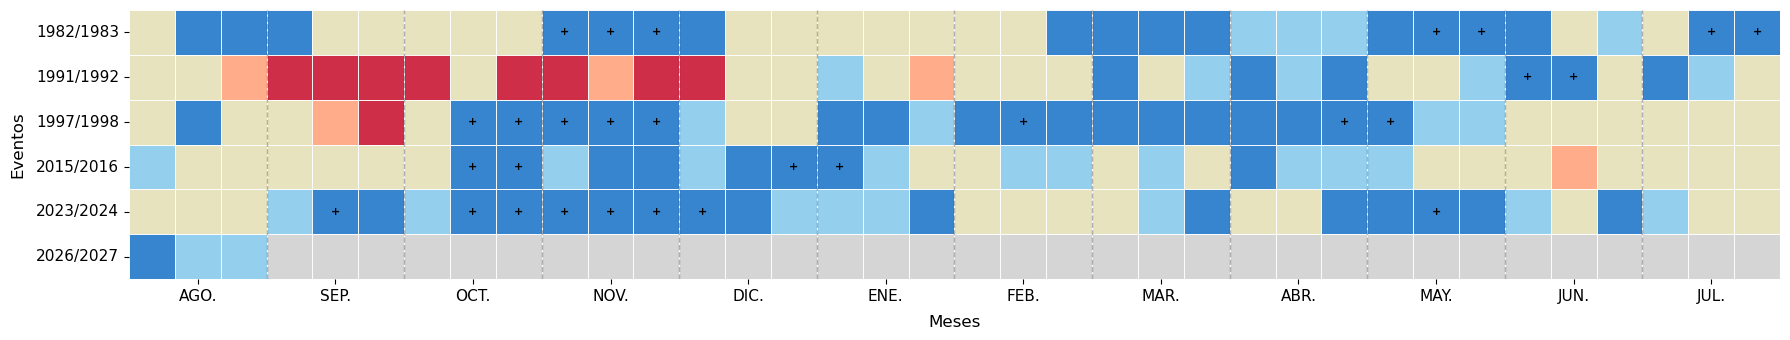

In [163]:
fig, ax = plot_dekad_event_heatmap(
    df=df_dekad_status,
    years_event=[1982, 1991, 1997, 2015, 2023, 2026],               # Años de inicio a comparar
    start_month=8,                                                  # Inicia en Agosto
    end_month=7,                                                    # Termina en Julio del año siguiente
    thresholds=[14000],                                              # Agrega '+' si el caudal supera 1750
    flowcat_col="flowcat",
    discharge_col="flow",
    date_col="startDate",
    figsize=(18, 3.5),
)

plt.show()

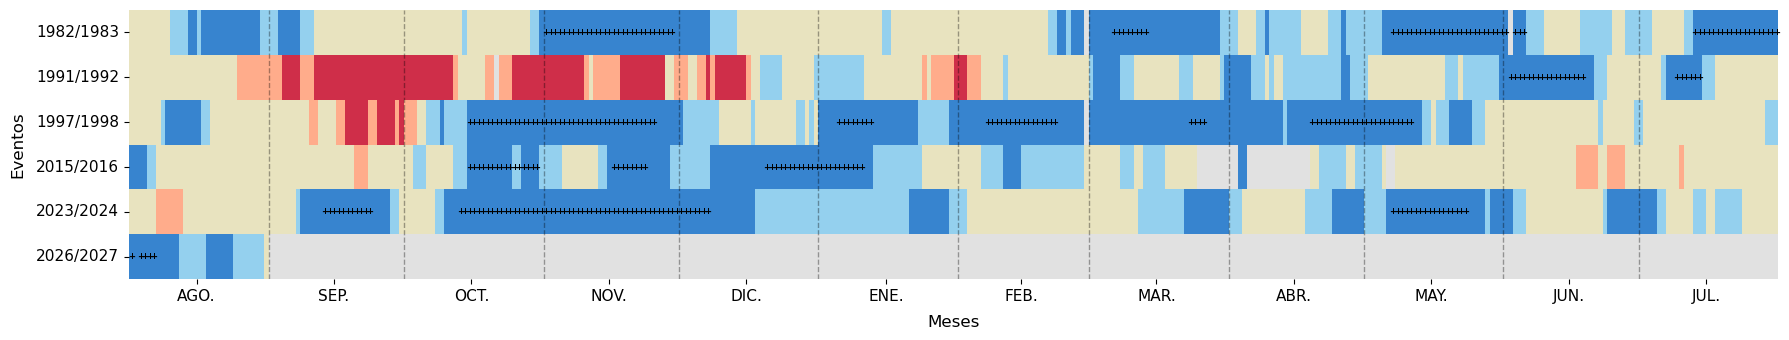

In [162]:
# Suponiendo que 'df_status_diarios' tiene: date, flow, status
fig2, ax2 = plot_daily_event_heatmap(
    df=df_daily_status,
    years_event=[1982, 1991, 1997, 2015, 2023, 2026],
    start_month=8,  # Agosto
    end_month=7,  # Julio del año siguiente
    thresholds=[14000],  # Marca '+' en días con caudal >= 1715 m3/s
    flowcat_col="flowcat",
    discharge_col="flow",
    date_col="date",
    figsize=(18, 3.5),
)